<a href="https://colab.research.google.com/github/PoddaC/Projeto-de-ML-para-analise-de-indicadores-de-ataques-cardiacos/blob/main/Hearth_disease_ML_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Previsão de Doença Cardíaca

Este notebook utiliza dados do BRFSS 2022 (CDC) para prever a probabilidade de uma pessoa ter sofrido ataque cardíaco, comparando três modelos de classificação.

## 1. Carregamento de Dados e Bibliotecas

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_recall_curve, roc_curve, roc_auc_score)

path = kagglehub.dataset_download("kamilpytlak/personal-key-indicators-of-heart-disease")

csvs = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
df = pd.read_csv([f for f in csvs if '2022_with_nans' in f][0])

print("Shape:", df.shape)
df.head()

100%|██████████| 21.4M/21.4M [00:01<00:00, 13.0MB/s]

Extracting files...


Shape: (445132, 40)


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df.head(10)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,Never smoked,Not at all (right now),No,"White only, Non-Hispanic",Age 80 or older,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 55 to 59,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,No,No,Yes,No,No,No,No,Yes,No,No,No,No,No,No,No,Current smoker - now smokes some days,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",NaN,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 40 to 44,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No
5,Alabama,Male,Poor,1.0,0.0,Within past year (anytime less than 12 months ...,No,7.0,NaN,Yes,No,Yes,No,No,No,No,No,No,Yes,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,1.80,84.82,26.08,No,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No
6,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Former smoker,Never used e-cigarettes in my entire life,No,"Black only, Non-Hispanic",Age 80 or older,1.65,62.60,22.96,Yes,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
7,Alabama,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 80 or older,1.63,73.48,27.81,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
8,Alabama,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,NaN,No,No,No,No,Yes,No,No,No,Yes,No,No,Yes,No,Yes,No,No,Former smoker,Not at all (right now),NaN,"White only, Non-Hispanic",Age 75 to 79,1.70,NaN,NaN,No,Yes,No,No,"Yes, received tetanus shot but not sure what type",No,No
9,Alabama,Female,Good,1.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,No,No,No,No,No,No,Yes,No,Yes,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,NaN,"White only, Non-Hispanic",Age 70 to 74,1.68,81.65,29.05,Yes,NaN,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


## 2. Exploração Inicial

In [2]:
print("Distribuição de HadHeartAttack:")
print(df['HadHeartAttack'].value_counts(normalize=True))

print("\nTop 10 colunas com mais NaNs (%):")
print((df.isnull().mean() * 100).sort_values(ascending=False).head(10))

Distribuição de HadHeartAttack:
HadHeartAttack
No     0.943203
Yes    0.056797
Name: proportion, dtype: float64

Top 10 colunas com mais NaNs (%):
TetanusLast10Tdap    18.537423
PneumoVaxEver        17.307226
HIVTesting           14.855593
ChestScan            12.590872
CovidPos             11.404258
HighRiskLastYear     11.372582
BMI                  10.964388
FluVaxLast12         10.585849
AlcoholDrinkers      10.462964
WeightInKilograms     9.452926
dtype: float64


Observação importante: a base é **fortemente desbalanceada** — apenas ~5,6% das pessoas tiveram ataque cardíaco. Isso vai impactar a escolha das métricas de avaliação.

## 3. Tratamento dos Dados

Preenchemos nulos (mediana para numéricas, moda para categóricas), convertemos a target para 0/1 e fazemos one-hot encoding nas categóricas.

In [3]:
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

df['HadHeartAttack'] = df['HadHeartAttack'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_encoded.drop('HadHeartAttack', axis=1)
y = df_encoded['HadHeartAttack']

print("Shape após encoding:", df_encoded.shape)

Shape após encoding: (445132, 122)


## 4. Modelo Base — Regressão Logística

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Acurácia:", accuracy_score(y_test, y_pred))

Acurácia: 0.9454772147775394


## 5. Verificação de Overfitting

In [5]:
print("Treino:", model.score(X_train, y_train))
print("Teste :", model.score(X_test, y_test))

scores = cross_val_score(model, X_train, y_train, cv=5)
print("CV média:", scores.mean(), "| desvio:", scores.std())

Treino: 0.946819056177251
Teste : 0.9454772147775394
CV média: 0.9467516603249042 | desvio: 0.0006659900636673925


Treino e teste praticamente iguais (~94%) e desvio do CV baixíssimo: **sem overfitting**.

## 6. A Armadilha da Acurácia

Apesar do alto valor, a acurácia engana num dataset desbalanceado. Vamos olhar a matriz de confusão.

In [6]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[82993   896]
 [ 3958  1180]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     83889
           1       0.57      0.23      0.33      5138

    accuracy                           0.95     89027
   macro avg       0.76      0.61      0.65     89027
weighted avg       0.93      0.95      0.93     89027



**Recall da classe 1 = 23%**: o modelo está apenas chutando "não" para quase todo mundo e ganhando acurácia de graça. Em contexto médico isso é inaceitável é preciso identificar os doentes.

## 7. Melhorando o Modelo com `class_weight='balanced'`

Esse parâmetro faz o modelo penalizar mais os erros na classe minoritária.

In [7]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[69678 14211]
 [ 1197  3941]]
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     83889
           1       0.22      0.77      0.34      5138

    accuracy                           0.83     89027
   macro avg       0.60      0.80      0.62     89027
weighted avg       0.94      0.83      0.87     89027



Recall saltou de 23% para 77%. A acurácia geral caiu para 83%, mas agora ela é honesta — o modelo de fato identifica casos positivos.

## 8. Análise dos Coeficientes e Seleção de Features

In [8]:
coefs = pd.Series(model.coef_[0], index=X.columns).abs().sort_values(ascending=False)
print(coefs.head(20))

HadAngina_Yes                                      2.495253
AgeCategory_Age 80 or older                        2.415086
AgeCategory_Age 75 to 79                           2.178624
AgeCategory_Age 70 to 74                           2.024596
AgeCategory_Age 65 to 69                           1.785444
AgeCategory_Age 60 to 64                           1.659601
AgeCategory_Age 55 to 59                           1.543270
AgeCategory_Age 50 to 54                           1.380970
AgeCategory_Age 45 to 49                           1.119002
HadStroke_Yes                                      1.118961
GeneralHealth_Poor                                 0.983317
GeneralHealth_Fair                                 0.848713
AgeCategory_Age 40 to 44                           0.807773
Sex_Male                                           0.738757
AgeCategory_Age 35 to 39                           0.634596
GeneralHealth_Good                                 0.603073
ChestScan_Yes                           

As features mais influentes batem com fatores de risco médicos conhecidos: angina prévia, idade avançada, AVC anterior, saúde geral ruim, sexo masculino, diabetes. Isso valida que o modelo aprendeu padrões reais.

In [9]:
top_features = coefs.head(20).index.tolist()
X_top = X[top_features]

X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.84      0.90     83889
           1       0.22      0.75      0.34      5138

    accuracy                           0.83     89027
   macro avg       0.60      0.79      0.62     89027
weighted avg       0.94      0.83      0.87     89027



Resultado praticamente idêntico ao modelo com 122 features — as outras 102 colunas eram ruído. Modelo agora está **83% mais leve** sem perder performance.

## 9. Ajuste de Threshold

O threshold padrão é 0.5. Podemos ajustá-lo para priorizar recall ou precision conforme o objetivo.

Melhor threshold (F1): 0.828
Precision: 0.437 | Recall: 0.492 | F1: 0.463


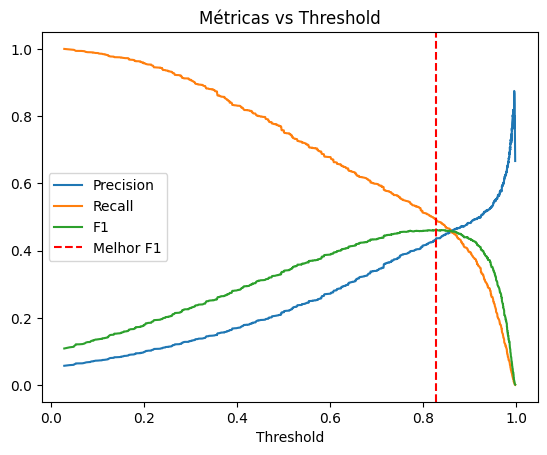

In [10]:
y_proba = model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1s = 2 * (precisions * recalls) / (precisions + recalls)

best_idx = f1s.argmax()
print(f"Melhor threshold (F1): {thresholds[best_idx]:.3f}")
print(f"Precision: {precisions[best_idx]:.3f} | Recall: {recalls[best_idx]:.3f} | F1: {f1s[best_idx]:.3f}")

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1s[:-1], label='F1')
plt.axvline(thresholds[best_idx], color='red', linestyle='--', label='Melhor F1')
plt.xlabel('Threshold')
plt.legend()
plt.title('Métricas vs Threshold')
plt.show()

Em contexto médico, threshold mais baixo (0.3–0.5) faz sentido: melhor alarmar um saudável (falso positivo) do que deixar passar um doente.

## 10. Matriz de Confusão (Heatmap)

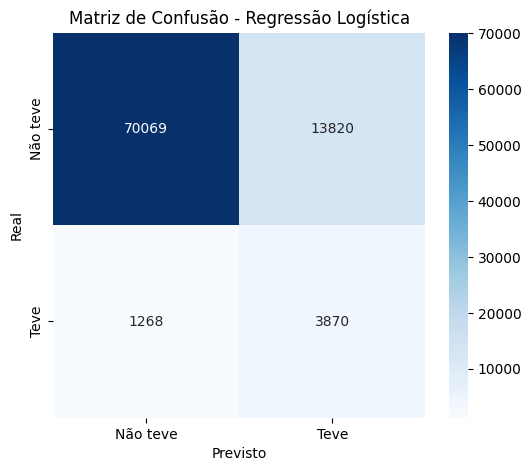

In [11]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não teve', 'Teve'],
            yticklabels=['Não teve', 'Teve'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

## 11. Comparação — Random Forest

In [12]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.82      0.89     83889
           1       0.20      0.75      0.32      5138

    accuracy                           0.82     89027
   macro avg       0.59      0.78      0.61     89027
weighted avg       0.94      0.82      0.86     89027



## 12. Comparação — Árvore de Decisão

Uma árvore pequena (`max_depth=4`) serve principalmente para visualizar o raciocínio do modelo.

              precision    recall  f1-score   support

           0       0.98      0.89      0.93     83889
           1       0.26      0.65      0.37      5138

    accuracy                           0.87     89027
   macro avg       0.62      0.77      0.65     89027
weighted avg       0.94      0.87      0.90     89027



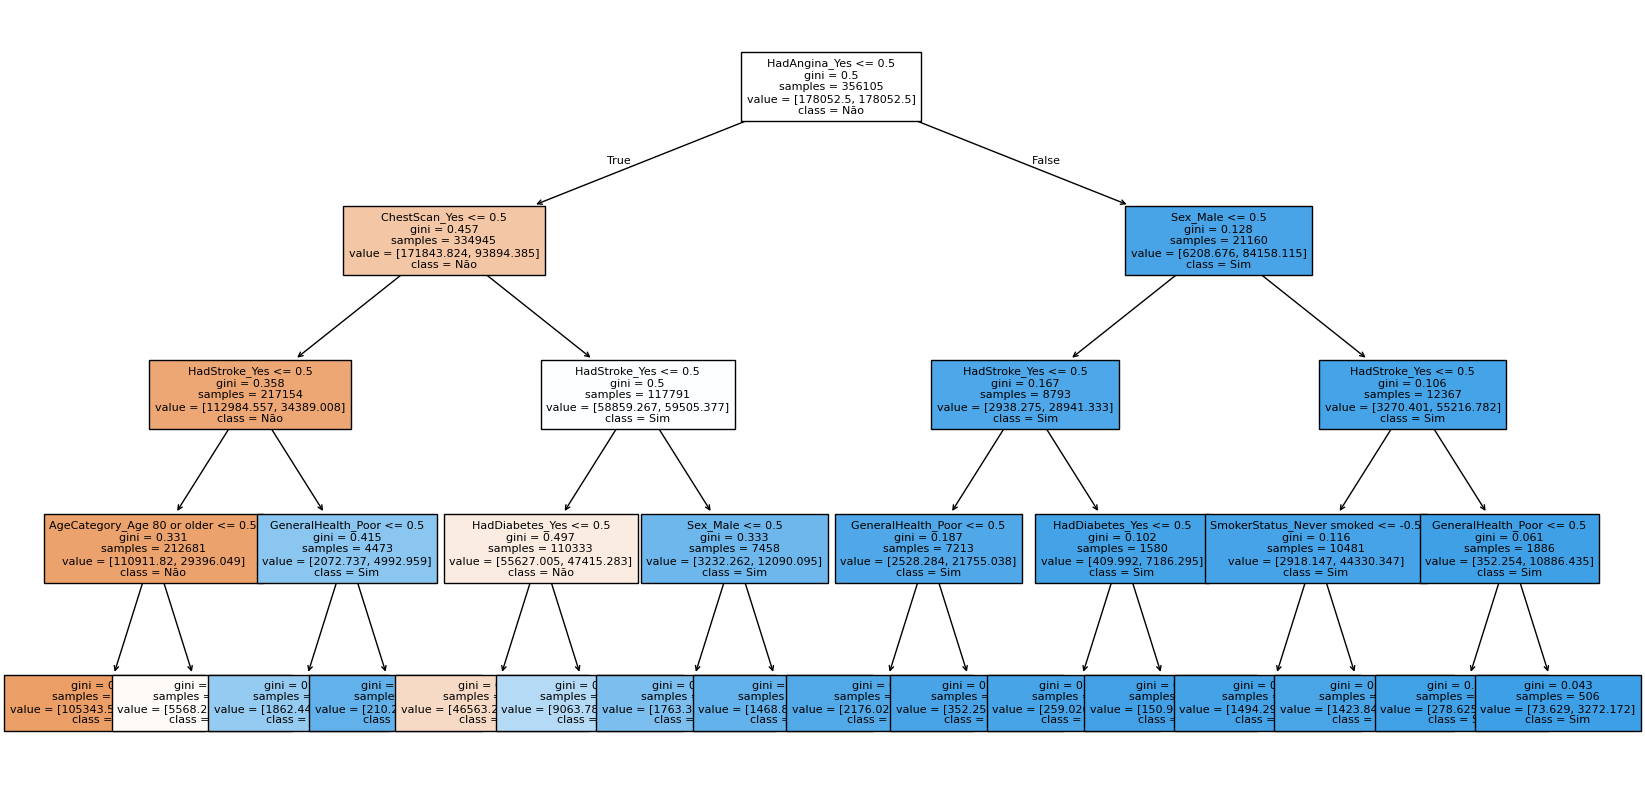

In [13]:
tree = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
tree.fit(X_train, y_train)

print(classification_report(y_test, tree.predict(X_test)))

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X_top.columns, class_names=['Não', 'Sim'], filled=True, fontsize=8)
plt.show()

## 13. Comparação Final — Curva ROC

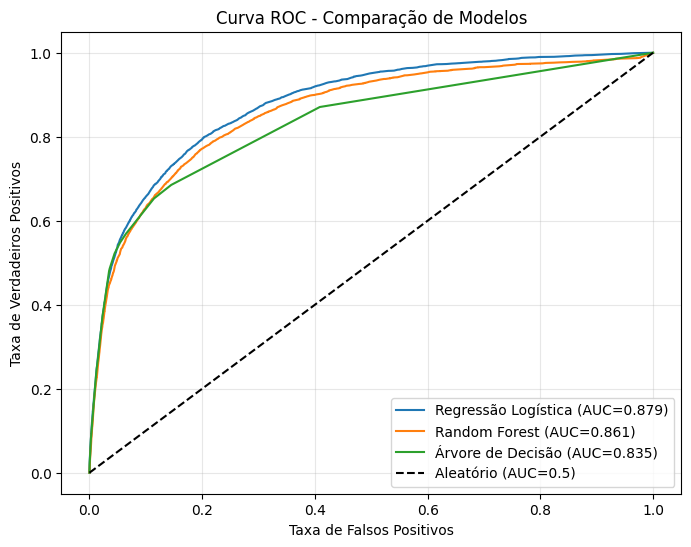

In [14]:
y_proba_log = model.predict_proba(X_test)[:, 1]
y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_proba_tree = tree.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree)

auc_log = roc_auc_score(y_test, y_proba_log)
auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_tree = roc_auc_score(y_test, y_proba_tree)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Regressão Logística (AUC={auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot(fpr_tree, tpr_tree, label=f'Árvore de Decisão (AUC={auc_tree:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC=0.5)')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Comparação de Modelos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 14. Conclusão

Este trabalho buscou prever a probabilidade de uma pessoa ter sofrido ataque cardíaco a partir de dados de saúde do BRFSS 2022 (CDC). O processo passou por carregamento e tratamento do dataset, codificação de variáveis categóricas, balanceamento de classes e comparação entre três modelos de classificação.

### Principais achados

- **Desbalanceamento severo**: apenas 5,6% da base teve ataque cardíaco, fazendo a acurácia (94%) ser uma métrica enganosa. O modelo padrão tinha recall de apenas 23% para a classe positiva, ou seja, deixava passar a maioria dos casos reais.

- **Ajuste de pesos** (`class_weight='balanced'`) elevou o recall para 77%, ao custo de mais falsos positivos — trade-off aceitável em contexto médico, onde deixar passar um doente é pior do que alarmar um saudável.

- **Redução de features**: das 122 colunas geradas pelo one-hot encoding, apenas 20 foram suficientes para manter a performance, simplificando o modelo sem perda significativa.

- **Comparação entre modelos** pela curva ROC:
  - Regressão Logística: **AUC = 0,879** (melhor)
  - Random Forest: AUC = 0,861
  - Árvore de Decisão: AUC = 0,835
  
  A vitória do modelo linear indica que o sinal nos dados é predominantemente aditivo, sem interações complexas que justifiquem modelos não-lineares.

- **Validação clínica**: as features mais influentes (angina prévia, idade avançada, AVC anterior, saúde geral ruim, sexo masculino, diabetes) coincidem com fatores de risco cardiovascular conhecidos na literatura médica, oque indica o aprendizado do modelo em padrões reais e não ruído.

### Limitações

- Recall máximo prático ficou em torno de 77–91% (dependendo do threshold), com precision baixa (14–22%) — ou seja, o modelo gera muitos falsos positivos.
- Os dados são auto-reportados (questionário), sujeitos a viés de memória e omissão.
- O modelo não substitui avaliação médica; deve ser entendido como ferramenta de **triagem** para identificar pessoas que merecem investigação clínica.

### Modelo final recomendado

Regressão Logística com `class_weight='balanced'`, treinada nas 20 features de maior coeficiente, com threshold ajustável conforme o objetivo (0,3 para máxima sensibilidade, 0,5 para equilíbrio padrão).